# Sentiment Model Training & Comparison
**HPDP Project 2 — SECP3133**

This notebook trains and compares **two** sentiment classifiers on Malaysian
banking/e-wallet app reviews, as required by the brief (at least two models,
evaluated with accuracy, precision, recall, F1 and a confusion matrix, on a
70/20/10 train/validation/test split). We cover one machine-learning and one
deep-learning model:

| # | Model | Category |
|---|-------|----------|
| 1 | Logistic Regression | Machine Learning |
| 2 | LSTM | Deep Learning |

### The imbalance problem
The labels are heavily skewed: **~77% negative**, ~16% positive, ~6% neutral.
A model that always predicts *negative* would score ~77% accuracy while being
useless. We handle this with **class weighting** (no synthetic data):

- **Stratified** 70/20/10 split so class ratios are identical across sets.
- **Balanced class weights** so errors on the rare classes (positive/neutral)
  are penalised proportionally more during training.
- Report **macro-averaged** precision/recall/F1 (every class counts equally)
  plus **per-class** metrics — not just accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Fixed label order -> consistent confusion matrices across all models
LABELS = ["negative", "neutral", "positive"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}

sns.set_style("whitegrid")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", DEVICE)

Torch: 2.12.1+cpu | Device: cpu


## 1. Load data

In [2]:
df = pd.read_csv("cleaned_data.csv")

# Use the already-cleaned/lemmatised text; drop rows that became empty.
df["cleaned_text"] = df["cleaned_text"].fillna("").astype(str).str.strip()
df = df[df["cleaned_text"] != ""].copy()
df = df[df["sentiment_label"].isin(LABELS)].copy()
df["label_id"] = df["sentiment_label"].map(LABEL2ID)

print("Usable rows:", len(df))
df["sentiment_label"].value_counts()

Usable rows: 16882


sentiment_label
negative    13068
positive     2740
neutral      1074
Name: count, dtype: int64

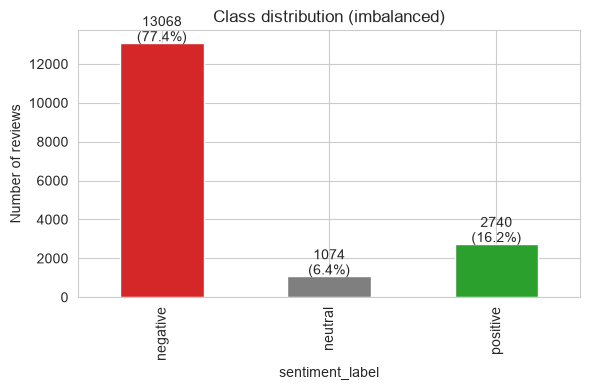

In [3]:
dist = df["sentiment_label"].value_counts().reindex(LABELS)
ax = dist.plot(kind="bar", color=["#d62728", "#7f7f7f", "#2ca02c"], figsize=(6, 4))
ax.set_title("Class distribution (imbalanced)")
ax.set_ylabel("Number of reviews")
for i, v in enumerate(dist):
    ax.text(i, v + 100, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
import os; os.makedirs("reports/figures", exist_ok=True)
plt.tight_layout()
plt.savefig("reports/figures/fig_class_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

## 2. Stratified 70 / 20 / 10 split
`stratify` keeps the negative/neutral/positive ratio identical in every split,
so validation and test scores reflect real-world performance.

In [4]:
X = df["cleaned_text"].values
y = df["label_id"].values

# First carve off 10% test, then split remainder into 70/20 (-> 0.20/0.90).
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20 / 0.90, stratify=y_temp, random_state=SEED)

for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    pct = np.bincount(yy, minlength=3) / len(yy) * 100
    print(f"{name:5s} n={len(yy):6d}  "
          f"neg {pct[0]:.1f}%  neu {pct[1]:.1f}%  pos {pct[2]:.1f}%")

Train n= 11816  neg 77.4%  neu 6.4%  pos 16.2%
Val   n=  3377  neg 77.4%  neu 6.4%  pos 16.2%
Test  n=  1689  neg 77.4%  neu 6.4%  pos 16.2%


### Class weights
`balanced` weight = `n_samples / (n_classes * count_of_class)`, so rarer classes
get larger weights. We reuse these weights for all three models.

In [5]:
class_weights = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_train)
print({ID2LABEL[i]: round(float(w), 3) for i, w in enumerate(class_weights)})

{'negative': 0.431, 'neutral': 5.245, 'positive': 2.054}


## 3. Shared evaluation helper
Every model is scored the same way: accuracy + macro/weighted precision, recall,
F1, a full per-class report, and a confusion matrix.

In [6]:
results = {}  # model_name -> metrics dict

def evaluate(name, y_true, y_pred, show=True):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    results[name] = {
        "Accuracy": acc,
        "Precision (macro)": p_macro, "Recall (macro)": r_macro,
        "F1 (macro)": f_macro, "F1 (weighted)": f_w,
    }
    if show:
        print(f"=== {name} ===")
        print(f"Accuracy: {acc:.4f} | Macro-F1: {f_macro:.4f} | Weighted-F1: {f_w:.4f}")
        print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        plt.figure(figsize=(4.5, 3.8))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=LABELS, yticklabels=LABELS)
        plt.title(f"Confusion Matrix — {name}")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        import os; os.makedirs("reports/figures", exist_ok=True)
        slug = {"Logistic Regression": "logreg", "LSTM": "lstm"}.get(name, name.lower().replace(" ", "_"))
        plt.tight_layout()
        plt.savefig(f"reports/figures/fig_confusion_{slug}.png", dpi=130, bbox_inches="tight")
        plt.show()
    return results[name]

## 4. TF-IDF features (for the two ML models)

In [7]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xtr_tfidf = tfidf.fit_transform(X_train)
Xval_tfidf = tfidf.transform(X_val)
Xte_tfidf = tfidf.transform(X_test)
print("TF-IDF shape:", Xtr_tfidf.shape)

TF-IDF shape: (11816, 20000)


## Model 1 — Logistic Regression (Machine Learning)
Uses `class_weight="balanced"` directly.

C:\Users\Owner\Dev\python\hpdp_project_2_new_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== Logistic Regression ===
Accuracy: 0.8851 | Macro-F1: 0.7263 | Weighted-F1: 0.8907
              precision    recall  f1-score   support

    negative       0.95      0.93      0.94      1307
     neutral       0.33      0.43      0.37       108
    positive       0.88      0.87      0.87       274

    accuracy                           0.89      1689
   macro avg       0.72      0.74      0.73      1689
weighted avg       0.90      0.89      0.89      1689



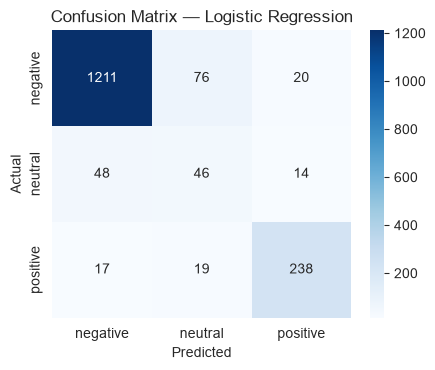

In [8]:
logreg = LogisticRegression(
    max_iter=2000, class_weight="balanced", C=1.0, n_jobs=-1, random_state=SEED)
logreg.fit(Xtr_tfidf, y_train)
evaluate("Logistic Regression", y_test, logreg.predict(Xte_tfidf));

## Model 2 — LSTM (Deep Learning, PyTorch)
A word-embedding + LSTM classifier. Imbalance is handled by passing the
**balanced class weights into the loss function** (`CrossEntropyLoss(weight=...)`),
the deep-learning analogue of `class_weight="balanced"`.

In [9]:
from collections import Counter

MAX_LEN = 60          # reviews are short after cleaning
MAX_VOCAB = 20000
PAD, UNK = 0, 1

# Build vocab from TRAIN ONLY (no leakage)
counter = Counter()
for t in X_train:
    counter.update(t.split())
itos = ["<pad>", "<unk>"] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
stoi = {w: i for i, w in enumerate(itos)}
print("Vocab size:", len(itos))

def encode(text):
    ids = [stoi.get(w, UNK) for w in text.split()[:MAX_LEN]]
    ids += [PAD] * (MAX_LEN - len(ids))
    return ids

class ReviewDS(Dataset):
    def __init__(self, texts, labels):
        self.x = torch.tensor([encode(t) for t in texts], dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], self.y[i]

train_dl = DataLoader(ReviewDS(X_train, y_train), batch_size=64, shuffle=True)
val_dl   = DataLoader(ReviewDS(X_val, y_val), batch_size=128)
test_dl  = DataLoader(ReviewDS(X_test, y_test), batch_size=128)

Vocab size: 10745


In [10]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab, emb=100, hid=128, n_cls=3):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=PAD)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(0.4)
        self.fc = nn.Linear(hid * 2, n_cls)
    def forward(self, x):
        e = self.drop(self.emb(x))
        out, _ = self.lstm(e)
        pooled = out.max(dim=1).values      # max-pooling over time
        return self.fc(self.drop(pooled))

model = LSTMClassifier(len(itos)).to(DEVICE)
weight_t = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight_t)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(model)

LSTMClassifier(
  (emb): Embedding(10745, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (drop): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)


In [11]:
def run_epoch(dl, train=True):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    preds_all, y_all = [], []
    with torch.set_grad_enabled(train):
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            loss_sum += loss.item() * len(yb)
            p = logits.argmax(1)
            correct += (p == yb).sum().item(); total += len(yb)
            preds_all += p.cpu().tolist(); y_all += yb.cpu().tolist()
    from sklearn.metrics import f1_score
    return loss_sum / total, correct / total, f1_score(y_all, preds_all, average="macro")

EPOCHS = 6
best_f1, best_state = -1, None
for ep in range(1, EPOCHS + 1):
    tl, ta, tf1 = run_epoch(train_dl, True)
    vl, va, vf1 = run_epoch(val_dl, False)
    print(f"Epoch {ep}: train_loss {tl:.3f} acc {ta:.3f} | "
          f"val_loss {vl:.3f} acc {va:.3f} macroF1 {vf1:.3f}")
    if vf1 > best_f1:                      # keep best model by val macro-F1
        best_f1 = vf1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
model.load_state_dict(best_state)
print(f"Best val macro-F1: {best_f1:.4f}")

Epoch 1: train_loss 0.925 acc 0.689 | val_loss 0.724 acc 0.655 macroF1 0.574


Epoch 2: train_loss 0.726 acc 0.737 | val_loss 0.625 acc 0.752 macroF1 0.639


Epoch 3: train_loss 0.639 acc 0.768 | val_loss 0.584 acc 0.827 macroF1 0.678


Epoch 4: train_loss 0.570 acc 0.788 | val_loss 0.576 acc 0.765 macroF1 0.648


Epoch 5: train_loss 0.530 acc 0.793 | val_loss 0.654 acc 0.842 macroF1 0.686


Epoch 6: train_loss 0.470 acc 0.816 | val_loss 0.645 acc 0.851 macroF1 0.695
Best val macro-F1: 0.6953


=== LSTM ===
Accuracy: 0.8431 | Macro-F1: 0.6893 | Weighted-F1: 0.8560
              precision    recall  f1-score   support

    negative       0.95      0.86      0.90      1307
     neutral       0.27      0.44      0.33       108
    positive       0.76      0.93      0.83       274

    accuracy                           0.84      1689
   macro avg       0.66      0.74      0.69      1689
weighted avg       0.88      0.84      0.86      1689



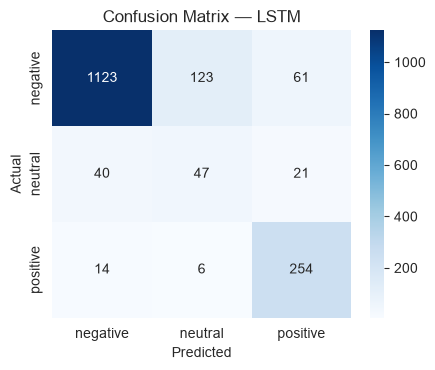

In [12]:
model.eval()
lstm_preds = []
with torch.no_grad():
    for xb, _ in test_dl:
        lstm_preds += model(xb.to(DEVICE)).argmax(1).cpu().tolist()
evaluate("LSTM", y_test, np.array(lstm_preds));

## 5. Model comparison

In [13]:
comp = pd.DataFrame(results).T.round(4)
comp = comp.sort_values("F1 (macro)", ascending=False)
display(comp)

,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Logistic Regression,0.8851,0.7168,0.7404,0.7263,0.8907
LSTM,0.8431,0.6590,0.7405,0.6893,0.8560


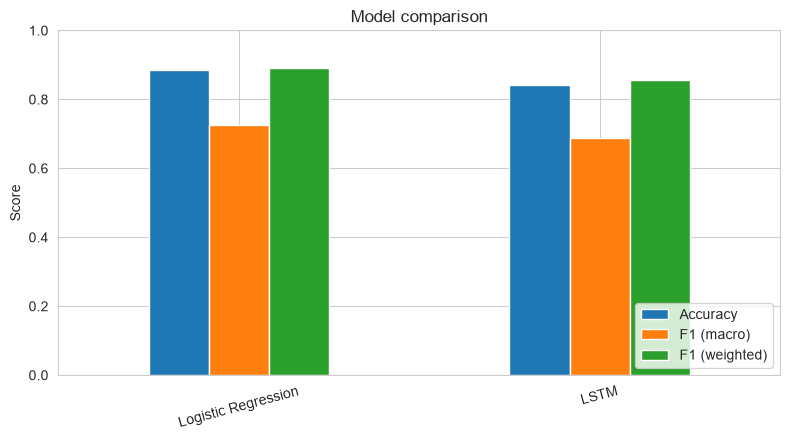

Best model by macro-F1: Logistic Regression (0.7263)


In [14]:
ax = comp[["Accuracy", "F1 (macro)", "F1 (weighted)"]].plot(
    kind="bar", figsize=(8, 4.5))
ax.set_title("Model comparison")
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.legend(loc="lower right")
import os; os.makedirs("reports/figures", exist_ok=True)
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig("reports/figures/fig_model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

best_name = comp.index[0]
print(f"Best model by macro-F1: {best_name} ({comp.loc[best_name, 'F1 (macro)']:.4f})")

## 6. Save artifacts
Saved for the Kafka/Spark pipeline stage. The best ML model + TF-IDF vectoriser
go to `models/`, and the LSTM weights + vocab alongside them.

In [15]:
import os, json, joblib
os.makedirs("models", exist_ok=True)

joblib.dump(tfidf, "models/tfidf_vectorizer.joblib")
joblib.dump(logreg, "models/logistic_regression.joblib")
torch.save({"state_dict": model.state_dict(), "itos": itos,
            "max_len": MAX_LEN}, "models/lstm.pt")

comp.to_csv("models/model_comparison.csv")
with open("models/label_map.json", "w") as f:
    json.dump({"id2label": ID2LABEL, "label2id": LABEL2ID}, f, indent=2)

print("Saved:", os.listdir("models"))

Saved: ['label_map.json', 'logistic_regression.joblib', 'lstm.pt', 'model_comparison.csv', 'tfidf_vectorizer.joblib']
